# Conclusion

- Original dataset : 268,632 * 33

**Dependent Variable**

- Outliers - All rents below 1 and above 100 €/m2 per month removed. Total of 64 datapoints removed. RE reason or data mis representation
- Tranformation - Rents are highly right tailed and therefore log tranformation implemented. New variable called "log_price_per_sqm"

**Independent Variable - Numeric**
- rent_per_sqm is baseRent/livingSpace. This is perfect multicollinearity and therefore both features are removed.
- Since totalRent = serviceCharge + baseRent, totalRent was removed.
- yearConstructed can be removed as it is same as buildingAge and have high correlation
- Floor ratio and numberOffloors seem to not have explanation power plus floor information already represented. Hence, they were removed
- finally **['serviceCharge', 'noRooms', 'building_age', 'amenity_score', 'condition_score', 'interior_score']** were included as numeric features
- R-squared is 0.25 which makes sense are the numerical data does not include location data

**Independent Variable - Numeric**
- In boolean features, only lift and hasKitchen seem to show signs any explanability power. Hence, all others removed.
- condition, interiorQual, typeOfFlat, heatingType and floor seems to show explanability, hence they are kept
- Location varibales City and State show good explanability. This is expected in a RE dataset. All other duplicate location variables removed.
- finally **['hasKitchen', 'lift', 'condition', 'interiorQual', 'typeOfFlat', 'heatingType', 'floor', 'city', 'state']** were included as categorical features

**Final dataset**

-  shape = 268,568 * 16

**Final**
The OLS model explains a substantial share of variation in log price per sqm (R² = 0.752), indicating strong overall fit. Structural and quality-related features, such as interior quality, condition, and amenities, significantly influence prices, while some variables (e.g., service charge, building age) are not statistically significant. Location effects are highly pronounced, with major cities like Munich, Frankfurt, and Berlin showing strong positive coefficients, highlighting spatial heterogeneity in housing markets. However, the extremely high condition number suggests severe multicollinearity, likely due to many correlated or dummy variables. While predictive performance is strong, coefficient interpretation should be treated with caution.

# Lib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis, probplot
import seaborn as sns
import statsmodels.api as sm

%matplotlib inline

# Loading Data

In [2]:
#loading data
df_og=pd.read_csv('data/immo_data_clean.csv')

In [3]:
# copying data to a new dataframe for eda
df = df_og.copy()
cols = list(df.columns)
print(df.shape)
display(df.head())

(268632, 33)


,regio1,serviceCharge,heatingType,newlyConst,balcony,totalRent,yearConstructed,hasKitchen,geo_bln,cellar,...,price_per_sqm,building_age,amenity_score,is_ground_floor,floor_ratio,condition_score,interior_score,central_heating,state,city
0,Nordrhein_Westfalen,245.00,central_heating,False,False,840.00,1965.0,False,Nordrhein_Westfalen,True,...,6.92,54.0,2,0,0.333,3,2,1,Nordrhein Westfalen,Dortmund
1,Rheinland_Pfalz,134.00,self_contained_central_heating,False,True,934.00,1871.0,False,Rheinland_Pfalz,False,...,8.99,148.0,1,0,0.667,6,2,0,Rheinland Pfalz,Rhein Pfalz Kreis
2,Sachsen,255.00,floor_heating,True,True,1300.00,2019.0,False,Sachsen,True,...,11.52,0.0,4,0,0.750,9,3,1,Sachsen,Dresden
3,Sachsen,58.15,district_heating,False,True,401.15,1964.0,False,Sachsen,False,...,5.90,55.0,1,0,1.000,5,2,1,Sachsen,Mittelsachsen Kreis
4,Bremen,138.00,self_contained_central_heating,False,True,903.00,1950.0,False,Bremen,False,...,9.00,69.0,1,0,0.333,6,2,0,Bremen,Bremen


# Outliers

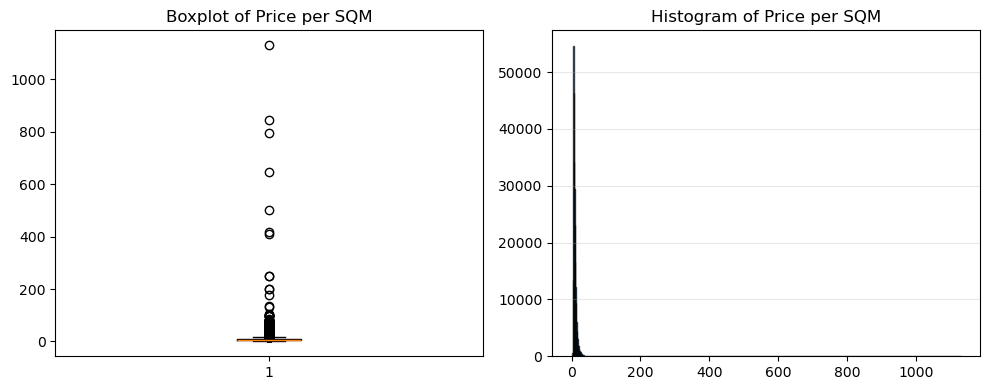

In [4]:
# shows box and hist
plt.figure(figsize=(10, 4))

# Left plot (1 row, 2 columns, plot 1)
plt.subplot(1, 2, 1)
plt.boxplot(df['price_per_sqm'])
plt.title("Boxplot of Price per SQM")

# Right plot (1 row, 2 columns, plot 2)
plt.subplot(1, 2, 2)
plt.hist(df['price_per_sqm'], bins=1000, edgecolor='black', alpha=0.7)
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Price per SQM")

plt.tight_layout()
plt.show()

In [5]:
#removing the rents above 100 €/sqm
df = df[df['price_per_sqm'] <= 100]
#removing the rents below 1 €/sqm
df = df[df['price_per_sqm'] >= 1]

print("Total data points after removing outliers: ", df_og.shape[0] - df.shape[0])

Total data points after removing outliers:  64


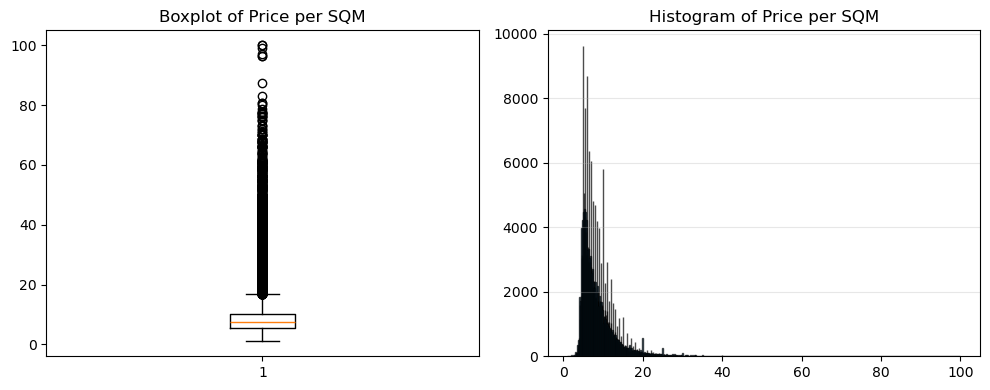

In [6]:
# shows box and hist
plt.figure(figsize=(10, 4))

# Left plot (1 row, 2 columns, plot 1)
plt.subplot(1, 2, 1)
plt.boxplot(df['price_per_sqm'])
plt.title("Boxplot of Price per SQM")

# Right plot (1 row, 2 columns, plot 2)
plt.subplot(1, 2, 2)
plt.hist(df['price_per_sqm'], bins=1000, edgecolor='black', alpha=0.7)
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Price per SQM")

plt.tight_layout()
plt.show()

In [7]:
# check distribution moments
print("Skewness:", skew(df['price_per_sqm']))
print("Kurtosis:", kurtosis(df['price_per_sqm']))

Skewness: 3.3695457625144356
Kurtosis: 22.16964674505116


# Tranformation - Dependent Variable

In [8]:
# performing a log tranformation
df['log_price_per_sqm'] = np.log(df['price_per_sqm'])

## Test for normality

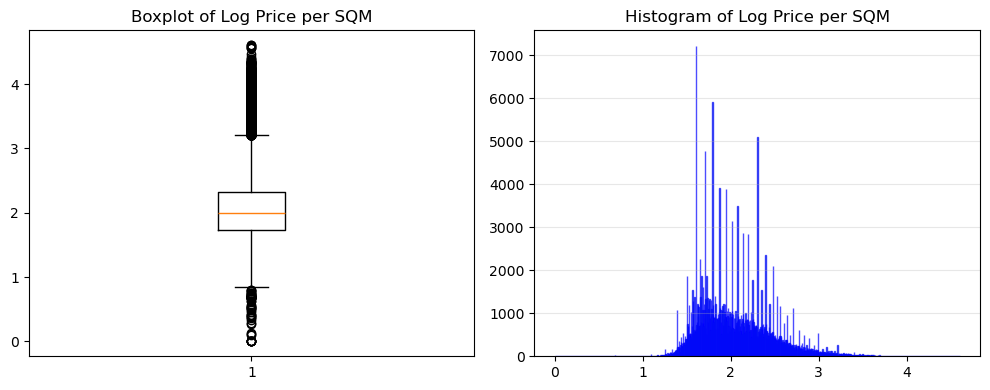

In [9]:
# shows box and hist
plt.figure(figsize=(10, 4))

# Left plot (1 row, 2 columns, plot 1)
plt.subplot(1, 2, 1)
plt.boxplot(df['log_price_per_sqm'])
plt.title("Boxplot of Log Price per SQM")

# Right plot (1 row, 2 columns, plot 2)
plt.subplot(1, 2, 2)
plt.hist(df['log_price_per_sqm'], bins=1000, edgecolor='blue', alpha=0.7)
plt.grid(axis='y', alpha=0.3)
plt.title("Histogram of Log Price per SQM")

plt.tight_layout()
plt.show()

In [10]:
# check distribution moments
print("Skewness:", skew(df['log_price_per_sqm']))
print("Kurtosis:", kurtosis(df['log_price_per_sqm']))

Skewness: 0.8390738110320434
Kurtosis: 0.919119921905712


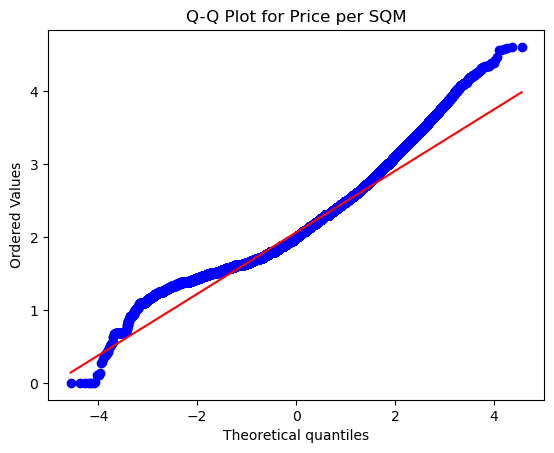

In [11]:
# Q-Q plot for price_per_sqm to check normality
probplot(df['log_price_per_sqm'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Price per SQM')
plt.show()

# Dependent variable - Numerical

In [12]:
print(cols)

['regio1', 'serviceCharge', 'heatingType', 'newlyConst', 'balcony', 'totalRent', 'yearConstructed', 'hasKitchen', 'geo_bln', 'cellar', 'baseRent', 'livingSpace', 'geo_krs', 'condition', 'interiorQual', 'lift', 'typeOfFlat', 'noRooms', 'floor', 'numberOfFloors', 'garden', 'regio2', 'regio3', 'price_per_sqm', 'building_age', 'amenity_score', 'is_ground_floor', 'floor_ratio', 'condition_score', 'interior_score', 'central_heating', 'state', 'city']


In [13]:
numeric_cols = ['serviceCharge', 'totalRent', 'yearConstructed', 'baseRent', 
                'livingSpace', 'noRooms', 'numberOfFloors', 'building_age', 
                'amenity_score', 'condition_score','floor_ratio', 
                'interior_score']

categorical_cols = ['heatingType', 'newlyConst', 'balcony', 'hasKitchen', 'central_heating', 'lift', 'is_ground_floor',
                     'cellar', 'condition', 'interiorQual', "floor",
                    'typeOfFlat', 'garden', 
                    'geo_bln','geo_krs','regio1','regio2', 'regio3', 'state', 'city']

## Correlation

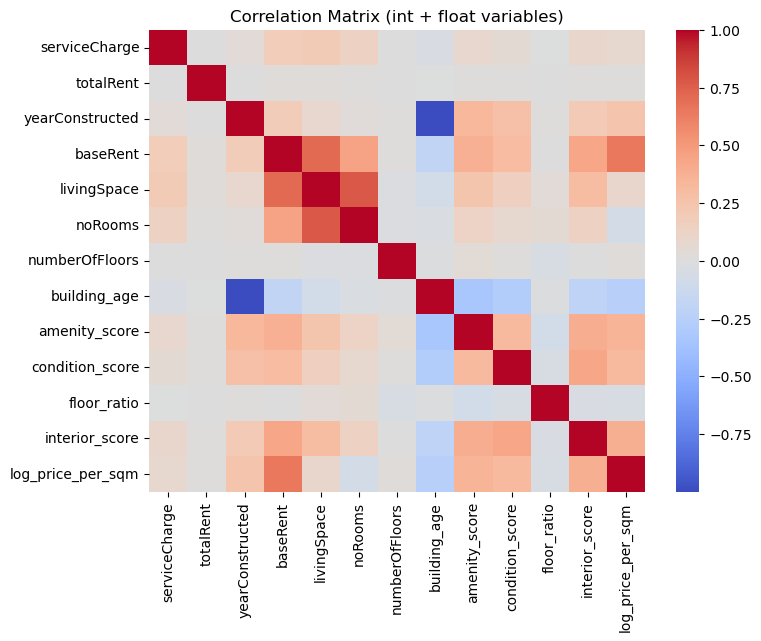

In [14]:
corr_matrix = df[numeric_cols + ["log_price_per_sqm"]].corr(method='pearson')   # or 'spearman'
#heatmaap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Matrix (int + float variables)")
plt.show()


# MLR

In [15]:
# Select numeric features
X = df[numeric_cols]
y = df["log_price_per_sqm"]
X = sm.add_constant(X)  # Add intercept
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:      log_price_per_sqm   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                 6.188e+04
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:50:42   Log-Likelihood:                 23080.
No. Observations:              268568   AIC:                        -4.613e+04
Df Residuals:                  268555   BIC:                        -4.600e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -75.2124      9.764     

# Removing features
points
- baseRent and livingSpace are highly correlated and can be removed
- serviceCharge and totalRent seem to not have a signficant impact p<0.05
- yearConstructed can be removed as it is same as buildingAge and have high correlation

In [16]:
# removing cols
numeric_cols = [x for x in numeric_cols if x not in ["totalRent", "baseRent", 
                                                     "livingSpace", "yearConstructed", 
                                                     "floor", "numberOfFloors", "floor_ratio"
                                                     ]]
print(numeric_cols)

['serviceCharge', 'noRooms', 'building_age', 'amenity_score', 'condition_score', 'interior_score']


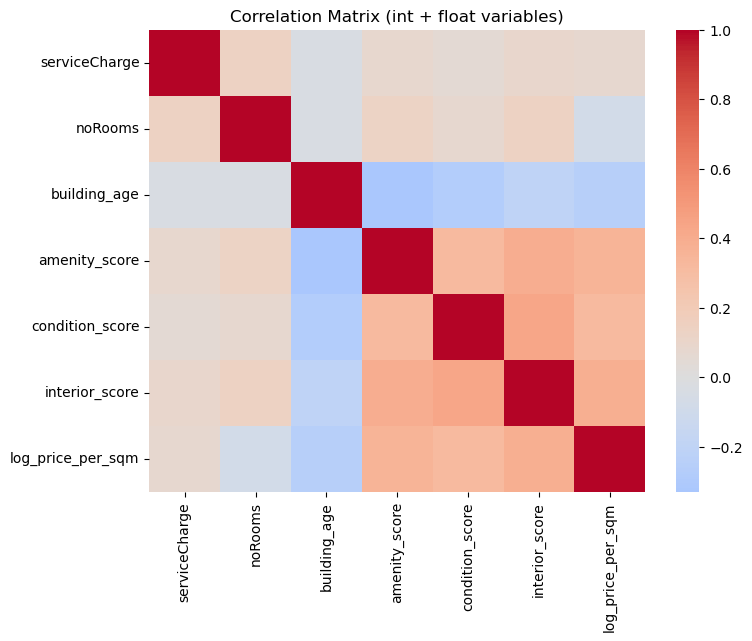

In [17]:
corr_matrix = df[numeric_cols + ["log_price_per_sqm"]].corr(method='pearson')   # or 'spearman'
#heatmaap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Matrix (int + float variables)")
plt.show()

In [18]:
# Select numeric features
X = df[numeric_cols]
y = df["log_price_per_sqm"]
X = sm.add_constant(X)  # Add intercept
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      log_price_per_sqm   R-squared:                       0.247
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                 1.469e+04
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:50:43   Log-Likelihood:            -1.1683e+05
No. Observations:              268568   AIC:                         2.337e+05
Df Residuals:                  268561   BIC:                         2.337e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.5370      0.004    3

# Dependent Variables - categorical

In [19]:
print(categorical_cols)

['heatingType', 'newlyConst', 'balcony', 'hasKitchen', 'central_heating', 'lift', 'is_ground_floor', 'cellar', 'condition', 'interiorQual', 'floor', 'typeOfFlat', 'garden', 'geo_bln', 'geo_krs', 'regio1', 'regio2', 'regio3', 'state', 'city']


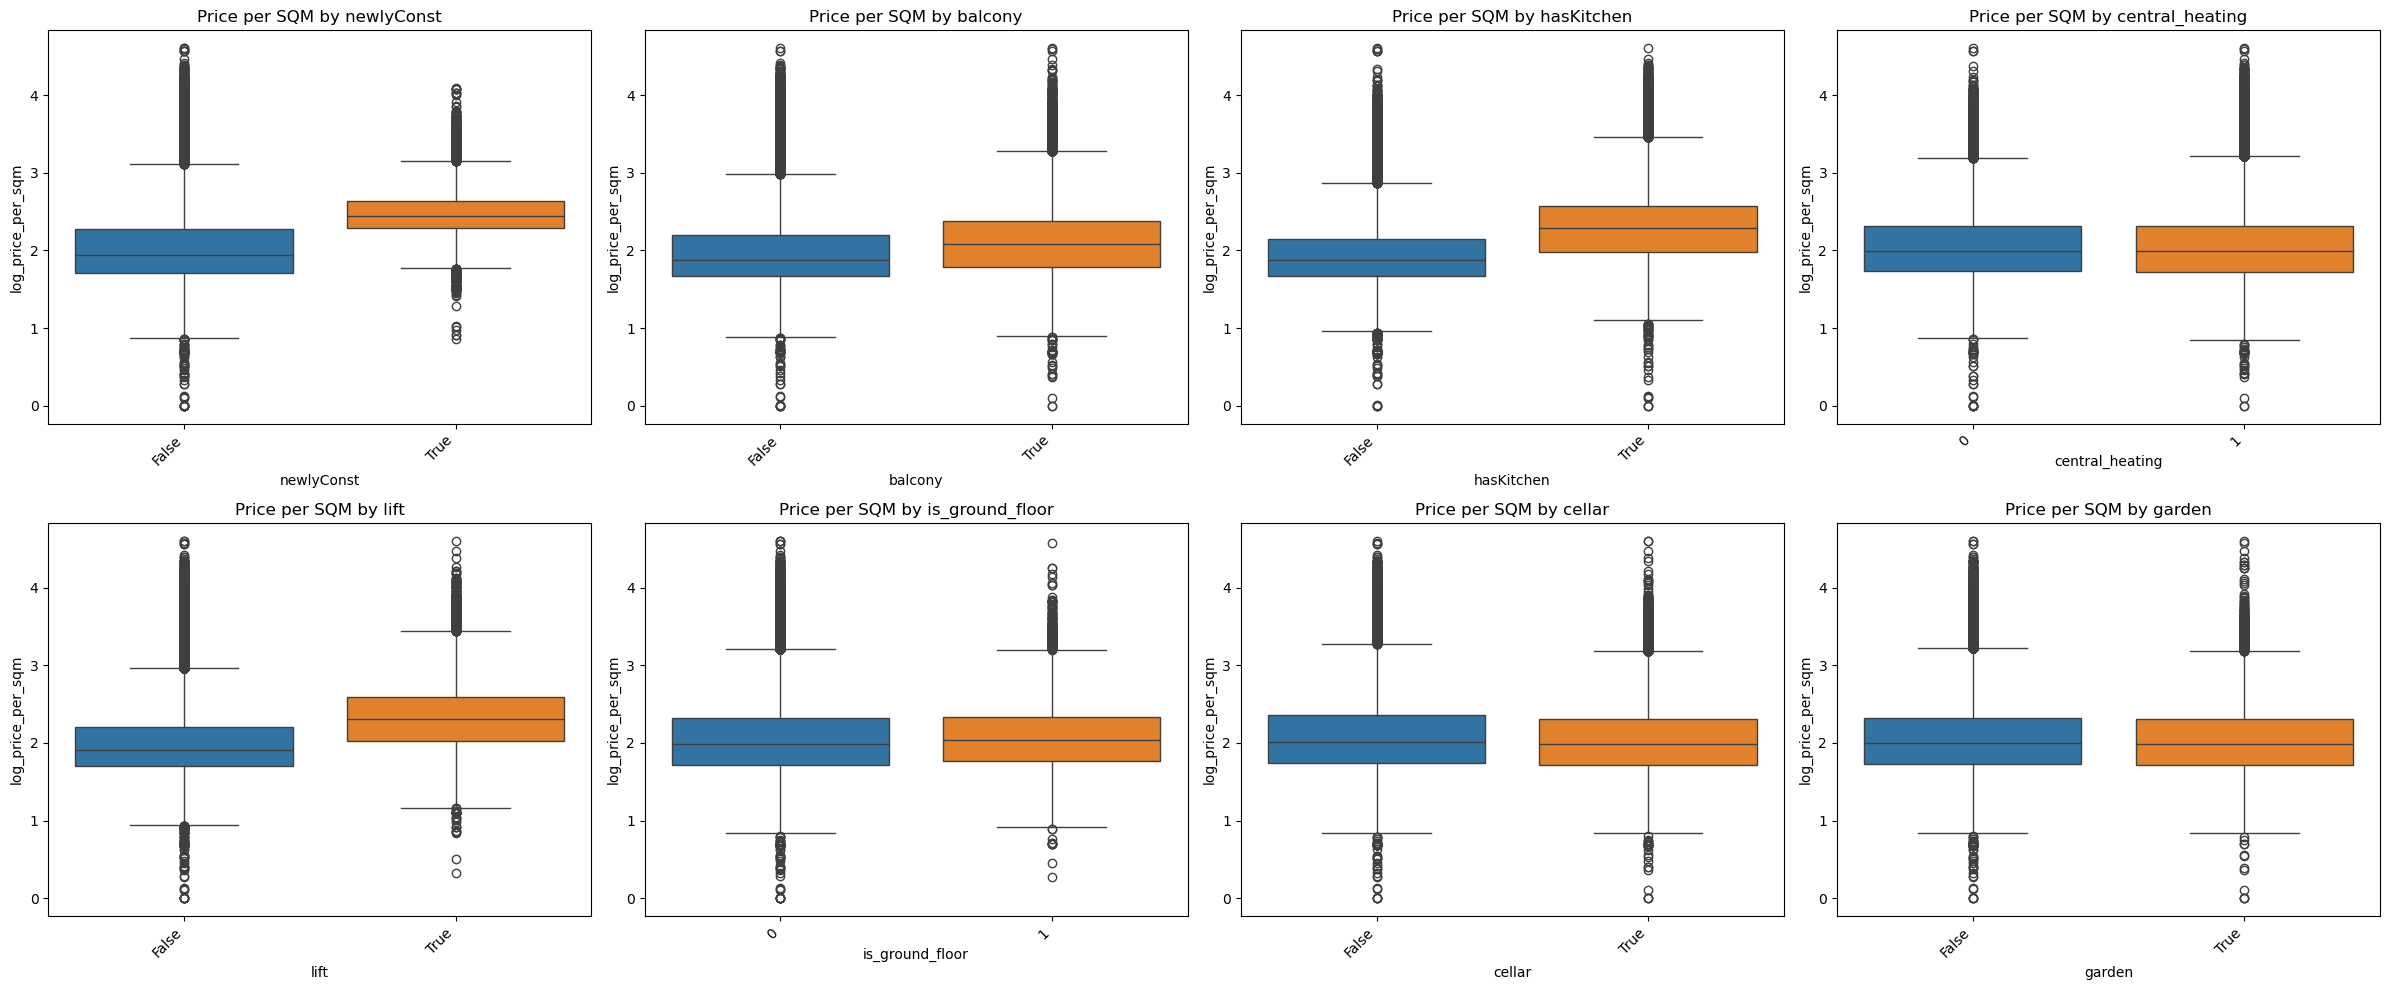

In [20]:
# checking explanability power of amenities
plot_cols = ['newlyConst', 'balcony',
                            'hasKitchen', 'central_heating', 'lift', 
                            'is_ground_floor', 'cellar', 'garden']

n = len(plot_cols)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(6 * cols, 5 * rows))
for idx, col in enumerate(plot_cols, start=1):
    plt.subplot(rows, cols, idx)
    sns.boxplot(x=col, y='log_price_per_sqm', data=df, hue=col, legend=False)
    plt.title(f'Price per SQM by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

#plt.suptitle('Boxplots: Categorical Features vs Price per SQM', y=1.02, fontsize=16)
plt.show()

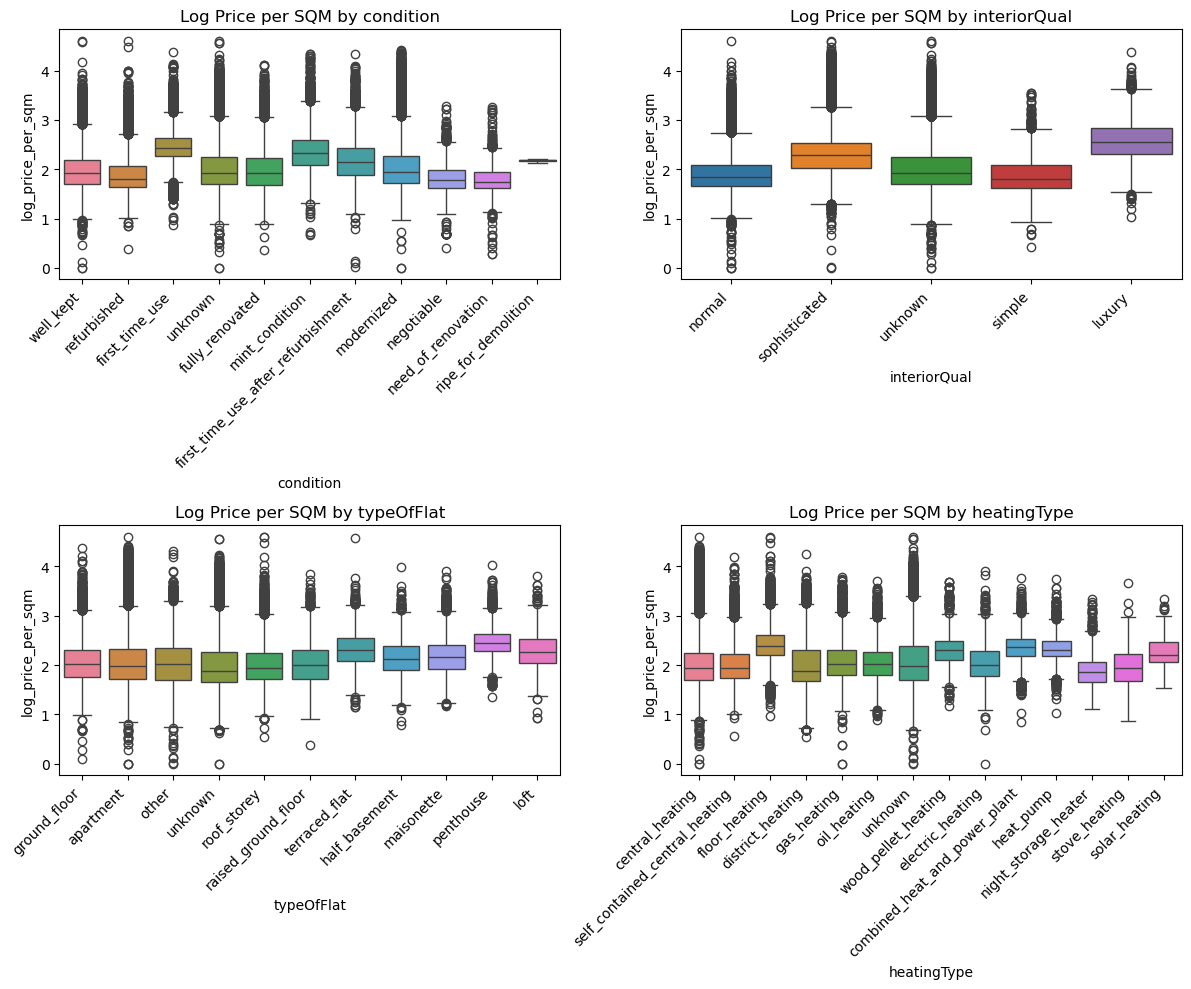

In [21]:
# category of flat and condition and interior quality
plot_cols = ['condition', 'interiorQual', 'typeOfFlat', 'heatingType']

n = len(plot_cols)
cols = 2
rows = (n + cols - 1) // cols

plt.figure(figsize=(6 * cols, 5 * rows))
for idx, col in enumerate(plot_cols, start=1):
    plt.subplot(rows, cols, idx)
    sns.boxplot(x=col, y='log_price_per_sqm', data=df, hue=col, legend=False)
    plt.title(f'Log Price per SQM by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

#plt.suptitle('Boxplots: Categorical Features vs Price per SQM', y=1.02, fontsize=16)
plt.show()

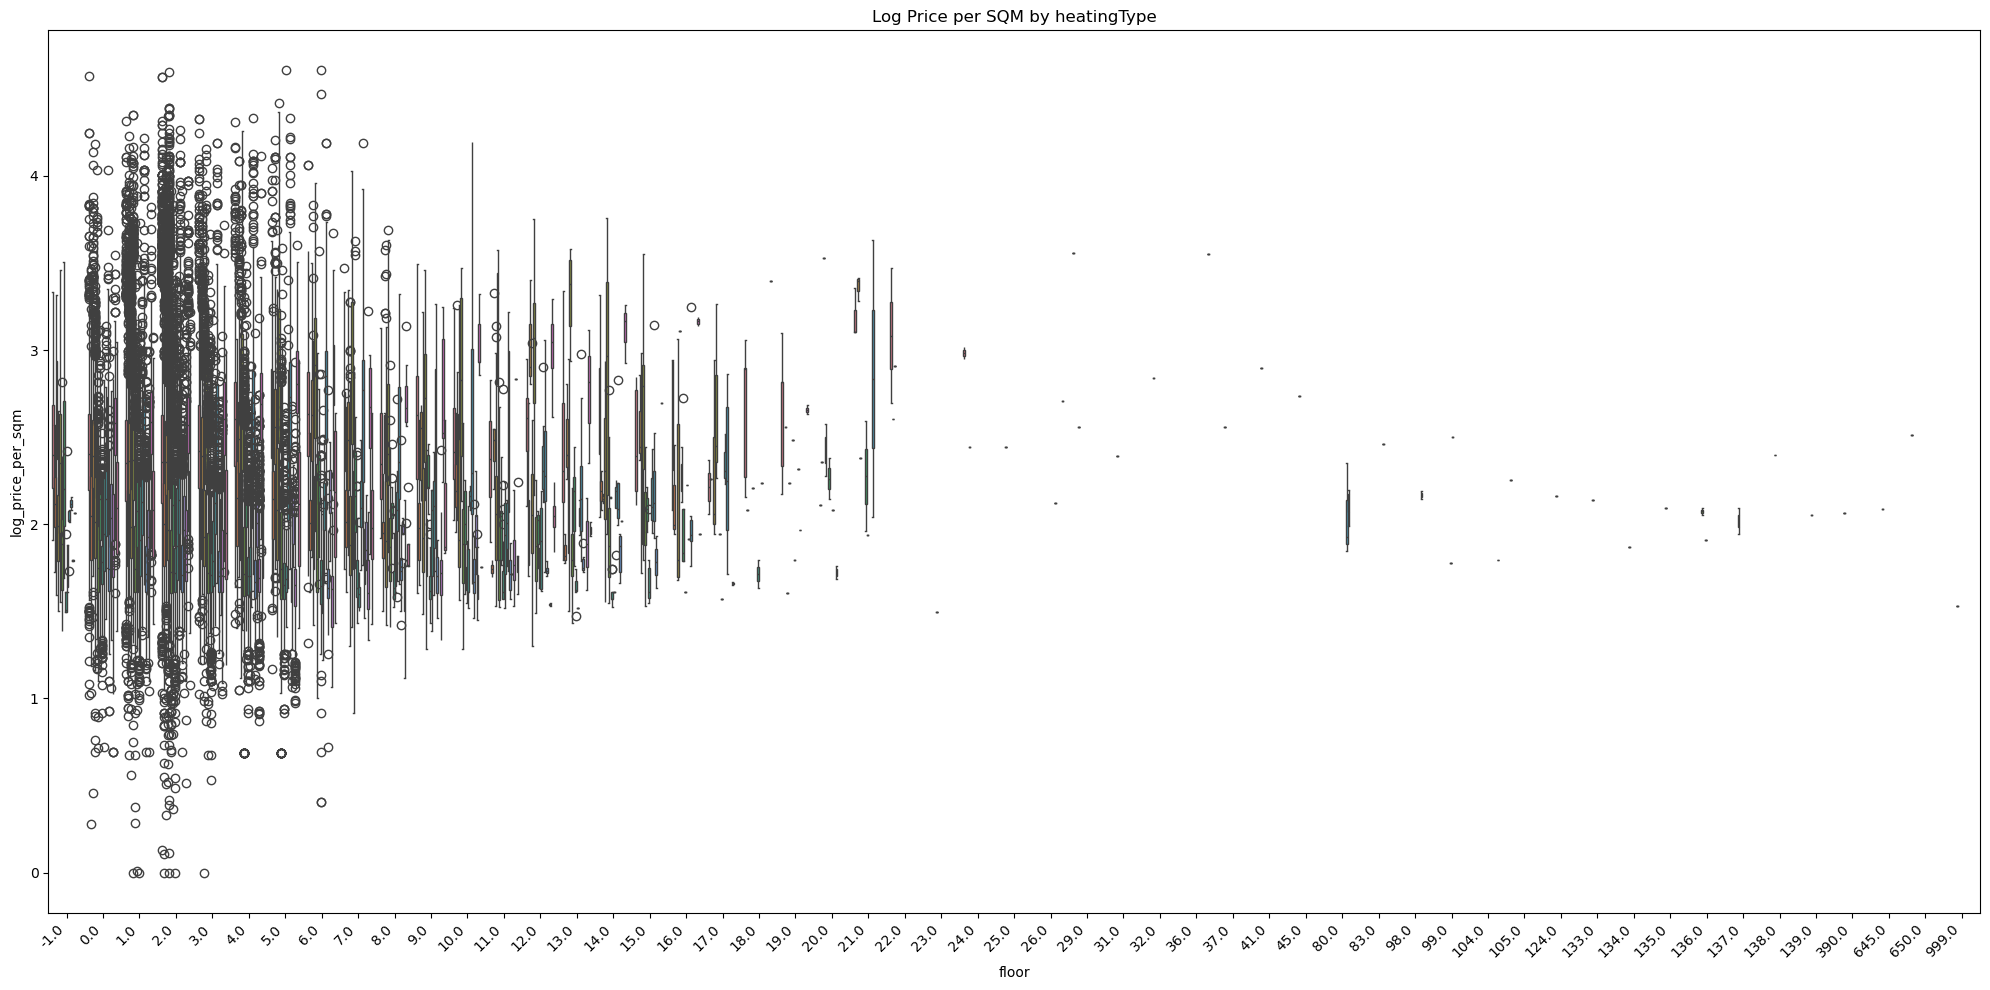

In [22]:
# boxplot of floor vs price per sqm
plt.figure(figsize=(20 , 10))
sns.boxplot(x='floor', y='log_price_per_sqm', data=df, hue='state', legend=False)
plt.title(f'Log Price per SQM by {col}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

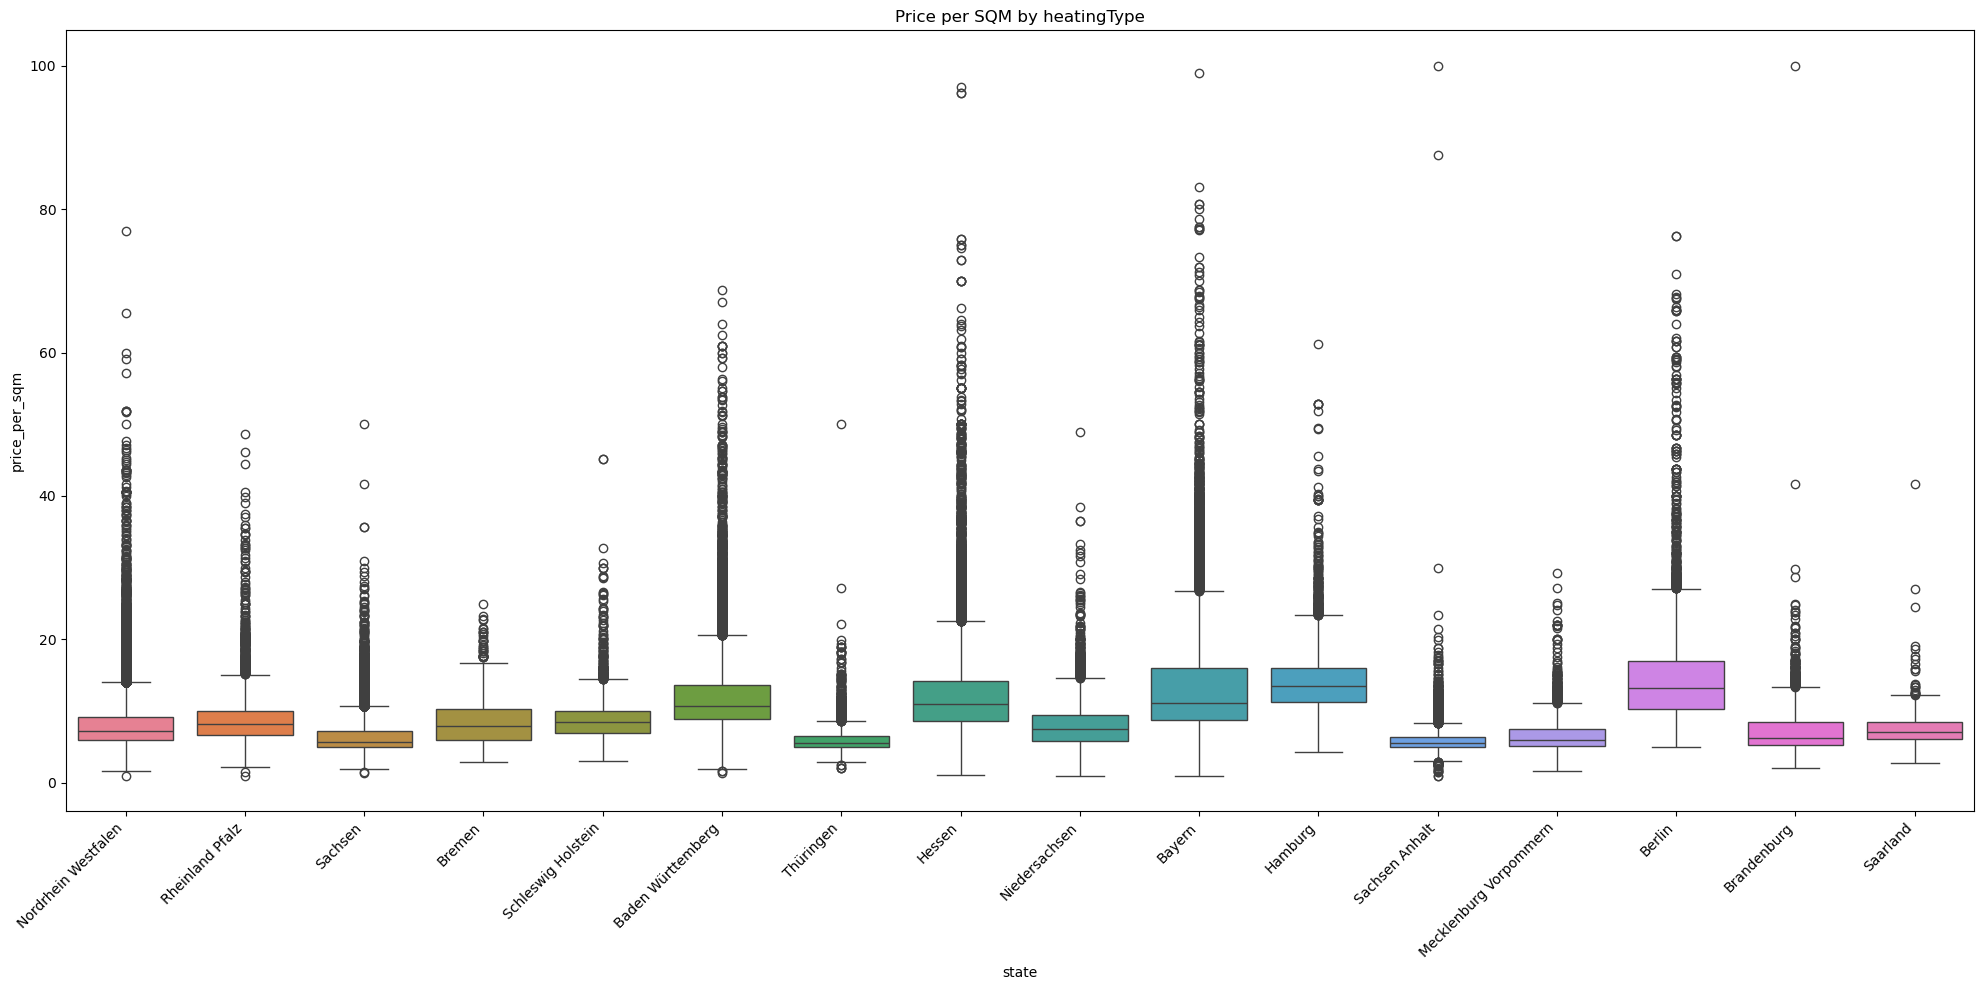

In [23]:
# boxplot of state vs price per sqm
plt.figure(figsize=(20 , 10))
sns.boxplot(x='state', y='price_per_sqm', data=df, hue='state', legend=False)
plt.title(f'Price per SQM by {col}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


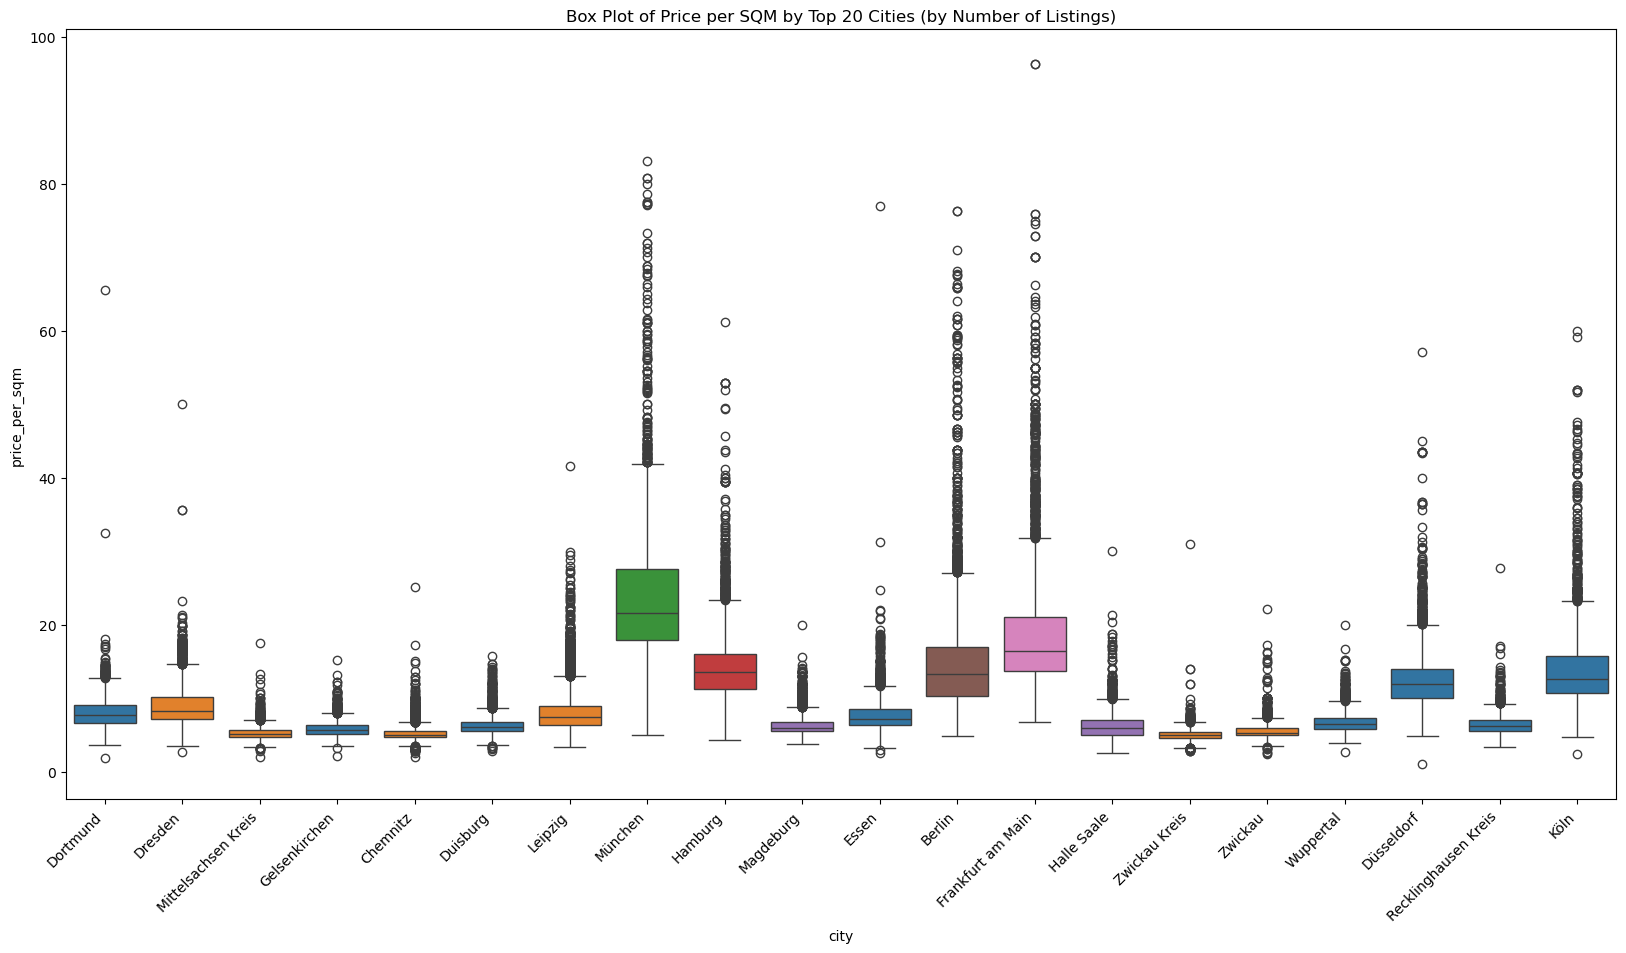

In [24]:
# boxplot of state vs price per sqm
# Get top 20 cities by number of rows
top_cities = df['city'].value_counts().head(20).index

# Filter df to only include top 20 cities
df_top_cities = df[df['city'].isin(top_cities)]

# Box plot of price_per_sqm by top 20 cities
plt.figure(figsize=(20 , 10))
sns.boxplot(x='city', y='price_per_sqm', data=df_top_cities, hue='state', legend=False)
plt.title('Box Plot of Price per SQM by Top 20 Cities (by Number of Listings)')
plt.xticks(rotation=45, ha='right')
plt.show()

# Final Dataset

In [25]:
numeric_cols_final = ['serviceCharge', 'noRooms', 'building_age', 
                      'amenity_score', 'condition_score', 'interior_score']

categorical_cols_final = ['hasKitchen', 'lift', # boolean features
                          'condition', 'interiorQual', 'typeOfFlat', 'heatingType', 'floor', # these are the most important categorical features based on boxplots
                          'city', 'state' # location features
                          ]

## Saving final dataset

In [26]:
df[numeric_cols_final + categorical_cols_final + ["log_price_per_sqm"]].to_csv('data/immo_data_clean_transformed.csv', index=False)
print(df[numeric_cols_final + categorical_cols_final + ["log_price_per_sqm"]].shape)

(268568, 16)


## OLS on final dataset

In [27]:
# normalization of numeric varaibles
df_num_normalized = (df[numeric_cols_final]-df[numeric_cols_final].mean())/df[numeric_cols_final].std()

#concatenating the normalized numeric features with the categorical features and target variable
df_model = pd.concat([df_num_normalized, 
                      df[categorical_cols_final], 
                      df[["log_price_per_sqm"]]], axis=1).dropna()

# Performing one-hot encoding for categorical variables
X = pd.get_dummies(df_model.drop(columns="log_price_per_sqm"), drop_first=True)
y = df_model["log_price_per_sqm"]

# converting all to float for statsmodels
X = X.astype(float)
X = sm.add_constant(X)

# performing OLS regression
model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      log_price_per_sqm   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     1762.
Date:                Sat, 28 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:51:31   Log-Likelihood:                 32434.
No. Observations:              268568   AIC:                        -6.394e+04
Df Residuals:                  268105   BIC:                        -5.908e+04
Df Model:                         462                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [28]:
results.params.sort_values(ascending=False).head(10)

const                            1.801392
city_München                     0.825323
city_Stuttgart                   0.687974
city_München Kreis               0.606641
city_Frankfurt am Main           0.577543
interiorQual_simple              0.523247
city_Starnberg Kreis             0.484300
city_Mainz                       0.471741
condition_ripe_for_demolition    0.427505
city_Fürstenfeldbruck Kreis      0.417685
dtype: float64

In [29]:
results.params.sort_values(ascending=True).head(10)

city_Höxter Kreis                        -0.494159
city_Wunsiedel im Fichtelgebirge Kreis   -0.474810
city_Tirschenreuth Kreis                 -0.465379
city_Lüchow Dannenberg Kreis             -0.462350
city_Hof Kreis                           -0.448452
city_Hochsauerlandkreis                  -0.446157
city_Hagen                               -0.433660
city_Märkischer Kreis                    -0.419504
city_Werra Meißner Kreis                 -0.418778
state_Sachsen                            -0.411663
dtype: float64